# **Pagerank Website ITS**

# **1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

# **2. Load Data**

In [ ]:
dataset = '/content/drive/MyDrive/Tugas6PPW/PPWCrawlingLink (3).csv'
data_page = pd.read_csv(dataset)

In [ ]:
display(data_page)

,id,page,link_keluar
0,1,https://www.its.ac.id/,https://www.its.ac.id/
1,2,https://www.its.ac.id/,https://www.its.ac.id/admission/
2,3,https://www.its.ac.id/,https://www.its.ac.id/current-student/
3,4,https://www.its.ac.id/,https://www.its.ac.id/fresher/
4,5,https://www.its.ac.id/,https://www.its.ac.id/lecturer-and-staff/
...,...,...,...
5483,5484,https://www.its.ac.id/public-services/secretar...,https://www.its.ac.id/about-its/its-awards/
5484,5485,https://www.its.ac.id/public-services/secretar...,https://www.its.ac.id/?page_id=11494
5485,5486,https://www.its.ac.id/public-services/secretar...,https://www.its.ac.id/about-its/executive-board/
5486,5487,https://www.its.ac.id/public-services/secretar...,https://www.its.ac.id/about-its/vision-and-mis...


# **3. Membangun Graph Menggunakan NetworkX**

In [ ]:
graph = nx.DiGraph()
edge = list(zip(data_page['page'], data_page['link_keluar']))
graph.add_edges_from(edge)

print(f"Jumlah node (page unik): {graph.number_of_nodes()}")
print(f"Jumlah edge (tautan): {graph.number_of_edges()}")

Jumlah node (page unik): 676
Jumlah edge (tautan): 3743


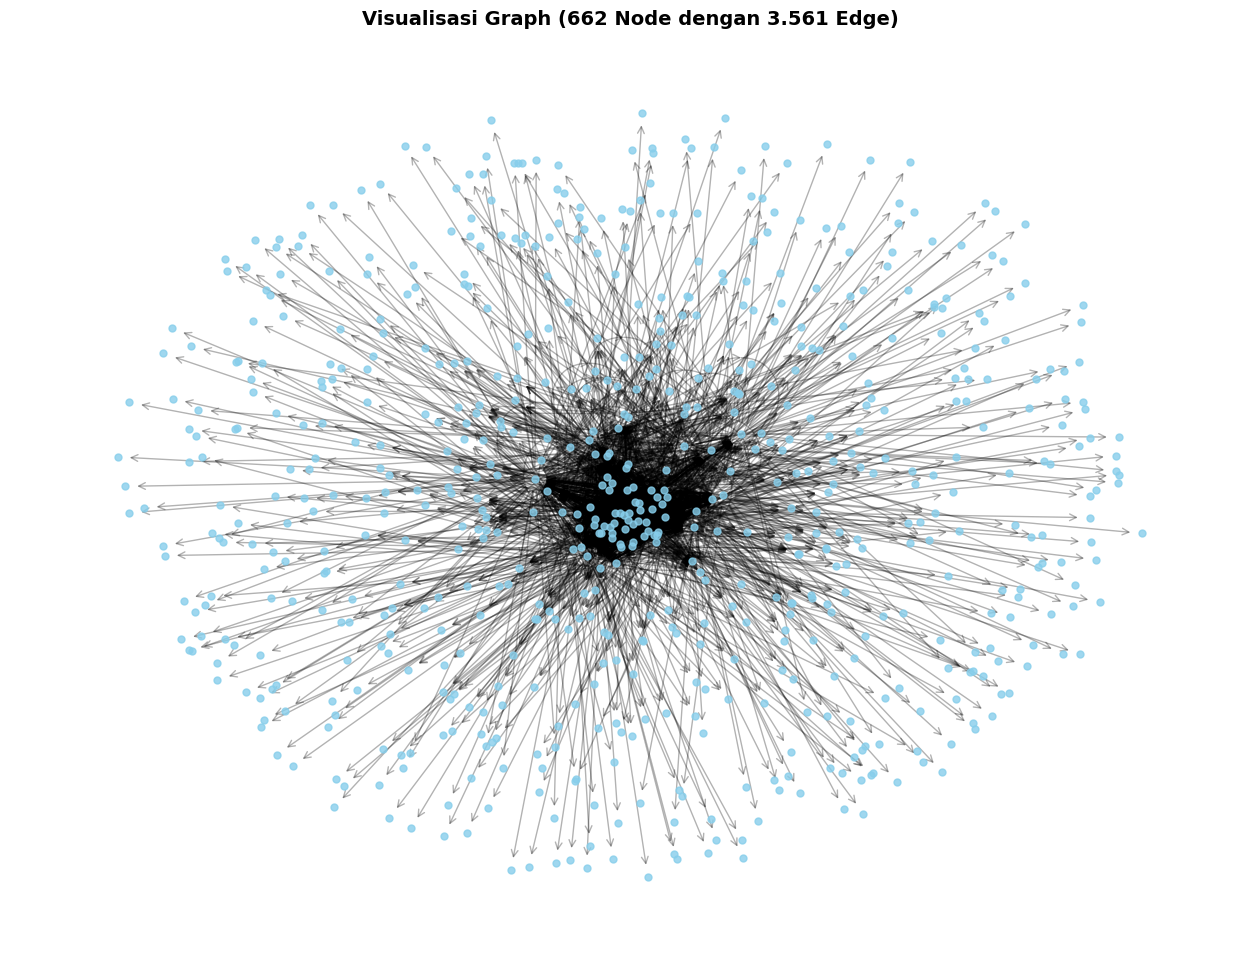

In [ ]:
# Visualisasi Graph
plt.figure(figsize=(16, 12))
plt.title("Visualisasi Graph (662 Node dengan 3.561 Edge)", fontsize=14, fontweight='bold')

# layout efisien untuk dataset besar
pos = nx.spring_layout(graph, seed=42, k=0.15, iterations=20)

# gambar node dan edge
nx.draw_networkx_nodes(graph, pos, node_color='skyblue', node_size=25, alpha=0.8)
# nx.draw_networkx_edges(graph, pos, edge_color='black', arrows=False, alpha=0.3)
nx.draw_networkx_edges(graph, pos, edge_color='black', arrowstyle='->', arrowsize=12, alpha=0.3)

# label, bisa ditampilkan (resiko visualisasi ga jelas karena link panjang). aktifkan :
# nx.draw_networkx_labels(graph, pos, font_size=6, font_color='black')

plt.axis('off')
plt.show()

# **4. Membentuk Matriks Adjacency (A)**

In [ ]:
# note: all matriks berukuran 662 x 662, sangat besar untuk ditampilkan
# jadi ditampilkan sebagian (misalnya 30x30)
page = list(graph.nodes())[:30]
A = nx.to_numpy_array(graph, nodelist=page, dtype=int)

data_page_A = pd.DataFrame(A, index=page, columns=page)
print("Matriks Adjacency (A) [30x30]:")
display(data_page_A)

Matriks Adjacency (A) [30x30]:


,https://www.its.ac.id/,https://www.its.ac.id/admission/,https://www.its.ac.id/current-student/,https://www.its.ac.id/fresher/,https://www.its.ac.id/lecturer-and-staff/,https://www.its.ac.id/parents/,https://www.its.ac.id/alumni/,https://www.its.ac.id/id/beranda/,https://www.its.ac.id/about-its/,https://www.its.ac.id/about-its/facts-and-history/,...,https://www.its.ac.id/admission/pascasarjana/,https://www.its.ac.id/admission/sarjana-terapan/,https://www.its.ac.id/admission/profesi/,https://www.its.ac.id/admission/iup/,https://www.its.ac.id/international/experiencing-its/prospective-student/,https://www.its.ac.id/study-at-its/#field,https://www.its.ac.id/campus-life/explore-its/,https://www.its.ac.id/campus-life/theres-always-something-interesting/,https://www.its.ac.id/study-at-its/study-program/,https://www.its.ac.id/international/
https://www.its.ac.id/,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
https://www.its.ac.id/admission/,0,1,0,0,0,0,0,0,0,0,...,1,0,1,1,1,0,0,0,0,0
https://www.its.ac.id/current-student/,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
https://www.its.ac.id/fresher/,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
https://www.its.ac.id/lecturer-and-staff/,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
https://www.its.ac.id/parents/,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
https://www.its.ac.id/alumni/,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
https://www.its.ac.id/id/beranda/,1,1,0,0,0,0,1,1,0,0,...,1,1,1,1,1,0,0,0,0,1
https://www.its.ac.id/about-its/,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
https://www.its.ac.id/about-its/facts-and-history/,1,1,1,1,1,1,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1


# **5. Membentuk Matriks Probabilitas Transisi Baris-Stokastik (P)**

In [ ]:
adj_full = nx.to_numpy_array(graph, dtype=float)
n = adj_full.shape[0]

# tangani dangling node (page tanpa link_keluar)
out_degree = adj_full.sum(axis=1)
for i in range(n):
    if out_degree[i] == 0:
        adj_full[i, :] = 1.0

# matriks transisi baris-stokastik
P = adj_full / adj_full.sum(axis=1, keepdims=True)

# tampilan sebagian matriks P
data_page_P = pd.DataFrame(P[:30, :30], columns=range(30), index=range(30))
print("Matriks Transisi (P) [30x30]:")
display(data_page_P)

Matriks Transisi (P) [30x30]:


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,...,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638
1,0.000000,0.032258,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.032258,0.000000,0.032258,0.032258,0.032258,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753,0.000000,0.010753,0.010753,...,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753,0.010753
3,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085,0.000000,0.014085,0.014085,...,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085,0.014085
4,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804,0.000000,0.009804,0.009804,...,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804,0.009804
5,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821,0.000000,0.012821,0.012821,...,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821,0.012821
6,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.010526,0.010526,0.000000,0.000000,0.000000,0.000000,0.010526,0.010526,0.000000,0.000000,...,0.010526,0.010526,0.010526,0.010526,0.010526,0.000000,0.000000,0.000000,0.000000,0.010526
8,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.000000,0.010638,0.010638,...,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638,0.010638
9,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658,0.000000,0.012658,0.012658,...,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658,0.012658


# **6. Membentuk Matriks Kolom-Stokastik (M)**

In [ ]:
# M = Pᵀ (kolom-stokastik)
M = P.T
data_page_M = pd.DataFrame(M[:30, :30], columns=range(30), index=range(30))
print("Matriks M = Pᵀ [30x30]:")
display(data_page_M)

Matriks M = Pᵀ [30x30]:


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.083333,0.010526,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
1,0.010638,0.032258,0.010753,0.014085,0.009804,0.012821,0.000000,0.010526,0.010638,0.012658,...,0.037037,0.001479,0.037037,0.043478,0.000000,0.011628,0.01,0.01,0.007692,0.00
2,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.000000,0.000000,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
3,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.000000,0.000000,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
4,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.000000,0.000000,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
5,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.000000,0.000000,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
6,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.083333,0.010526,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
7,0.010638,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010526,0.000000,0.000000,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.000000,0.00,0.00,0.000000,0.00
8,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.000000,0.000000,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00
9,0.010638,0.000000,0.010753,0.014085,0.009804,0.012821,0.000000,0.000000,0.010638,0.012658,...,0.000000,0.001479,0.000000,0.000000,0.000000,0.011628,0.01,0.01,0.007692,0.00


# **7. Menghitung PageRank Iteratif (Manual)**

In [ ]:
def pagerank_iteratif(M, pagelist, d=0.85, max_iter=100, tol=1e-6):
    n = M.shape[0]
    r = np.ones(n) / n
    teleport = (1 - d) / n

    for i in range(max_iter):
        r_new = d * M @ r + teleport
        # debugging aja
        indeks_top_page = np.argmax(r_new)  # indeks page dengan PageRank tertinggi
        top_page = pagelist[indeks_top_page] # page dengan score pagerank tertinggi
        print(f"Iterasi {i+1}: Page {top_page} dengan PageRank {r_new[indeks_top_page]:.6f}")
        if np.linalg.norm(r_new - r, 1) < tol:
            # debugging aja
            print(f"Konvergen setelah {i+1} iterasi")
            break
        r = r_new
    return r

print("Menghitung PageRank:")

urutan_page = list(graph.nodes())
r = pagerank_iteratif(M, pagelist=urutan_page, d=0.85, max_iter=100, tol=1e-6)

Menghitung PageRank:
Iterasi 1: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002246
Iterasi 2: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002527
Iterasi 3: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002623
Iterasi 4: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002655
Iterasi 5: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002666
Iterasi 6: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002670
Iterasi 7: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002671
Iterasi 8: Page https://www.its.ac.id/international/experiencing-its/prospective-student/ dengan PageRank 0.002671
Iterasi 9: Page https://www.its.ac.id/international/experie

# **8. Menampilkan dan Menyimpan Hasil PageRank**

## **1. Semua Page**

In [ ]:
score_pagerank = pd.DataFrame({
    'page': list(graph.nodes()),
    'pagerank': r
})

# mengurutkan nilai PageRank tertinggi ke terendah
data_pagerank_page = score_pagerank.sort_values(by='pagerank', ascending=False).reset_index(drop=True)
print("Data Page dan Score PageRank:")
display(data_pagerank_page)

Data Page dan Score PageRank:


,page,pagerank
0,https://www.its.ac.id/international/experienci...,0.002671
1,https://www.its.ac.id/admission/sarjana/,0.002594
2,https://www.its.ac.id/admission/,0.002594
3,https://www.its.ac.id/admission/pascasarjana/,0.002505
4,https://www.its.ac.id/admission/profesi/,0.002505
...,...,...
671,https://www.its.ac.id/id/layanan/penjaminan-mutu/,0.001353
672,https://www.its.ac.id/id/layanan/audit-internal/,0.001353
673,https://www.its.ac.id/id/kuliah-di-its/fakulta...,0.001353
674,https://www.its.ac.id/kuliah-di-its/#bidang,0.001353


In [ ]:
data_pagerank_page.to_csv("PPW_Tugas6_LinkDalamPage_PageRank(Manual).csv", index=False)

## **2. 5 Page**

In [ ]:
lima_page_penting = data_pagerank_page.head(5)
print("5 Page dengan Nilai PageRank Tertinggi:")
display(lima_page_penting)

5 Page dengan Nilai PageRank Tertinggi:


,page,pagerank
0,https://www.its.ac.id/international/experienci...,0.002671
1,https://www.its.ac.id/admission/sarjana/,0.002594
2,https://www.its.ac.id/admission/,0.002594
3,https://www.its.ac.id/admission/pascasarjana/,0.002505
4,https://www.its.ac.id/admission/profesi/,0.002505


# **9. Perbandingan: Menghitung dan Menampilkan Hasil PageRank Menggunakan NetworkX**

## **1. Semua Page**

In [ ]:
score_pagerank_networkx = nx.pagerank(graph, alpha=0.85)
data_pagerank_page_networkx = pd.DataFrame(list(score_pagerank_networkx.items()), columns=['page', 'pagerank'])

# page score pagerank tertinggi ke terendah
data_page_pagerank_networkx_urut = data_pagerank_page_networkx.sort_values(by='pagerank', ascending=False).reset_index(drop=True)
print("Perbandingan Menggunakan NetworkX - Data Page dan Score PageRank:")
display(data_page_pagerank_networkx_urut)

Perbandingan Menggunakan NetworkX - Data Page dan Score PageRank:


,page,pagerank
0,https://www.its.ac.id/international/experienci...,0.002670
1,https://www.its.ac.id/admission/sarjana/,0.002592
2,https://www.its.ac.id/admission/,0.002592
3,https://www.its.ac.id/admission/pascasarjana/,0.002504
4,https://www.its.ac.id/admission/profesi/,0.002504
...,...,...
671,https://www.its.ac.id/id/layanan/penjaminan-mutu/,0.001353
672,https://www.its.ac.id/id/layanan/audit-internal/,0.001353
673,https://www.its.ac.id/id/kuliah-di-its/fakulta...,0.001353
674,https://www.its.ac.id/kuliah-di-its/#bidang,0.001353


In [ ]:
# OPSIONAL
# kalau mau simpan hasil data page dan score pagerank pembanding menggunakan NetworkX, aktifkan :
# data_page_pagerank_networkx_urut.to_csv("PPW_Tugas6_LinkDalamPage_PageRank(NetworkX).csv", index=False)

## **2. 5 Page**

In [ ]:
lima_page_penting_networkx = data_page_pagerank_networkx_urut.head(5)

print("5 Page dengan Nilai PageRank Tertinggi (NetworkX):")
display(lima_page_penting_networkx)

5 Page dengan Nilai PageRank Tertinggi (NetworkX):


,page,pagerank
0,https://www.its.ac.id/international/experienci...,0.002670
1,https://www.its.ac.id/admission/sarjana/,0.002592
2,https://www.its.ac.id/admission/,0.002592
3,https://www.its.ac.id/admission/pascasarjana/,0.002504
4,https://www.its.ac.id/admission/profesi/,0.002504


# **10. Visualisasi Hubungan Page Penting dengan Page Terhubung**

In [ ]:
page_penting = lima_page_penting.iloc[0]['page']
print(f"Page dengan nilai PageRank tertinggi: {page_penting}")

neighbors_out = list(graph.successors(page_penting))
neighbors_in = list(graph.predecessors(page_penting))
page_terhubung = set(neighbors_out + neighbors_in + [page_penting])
subgraph_page_terhubung = graph.subgraph(page_terhubung)

Page dengan nilai PageRank tertinggi: https://www.its.ac.id/international/experiencing-its/prospective-student/


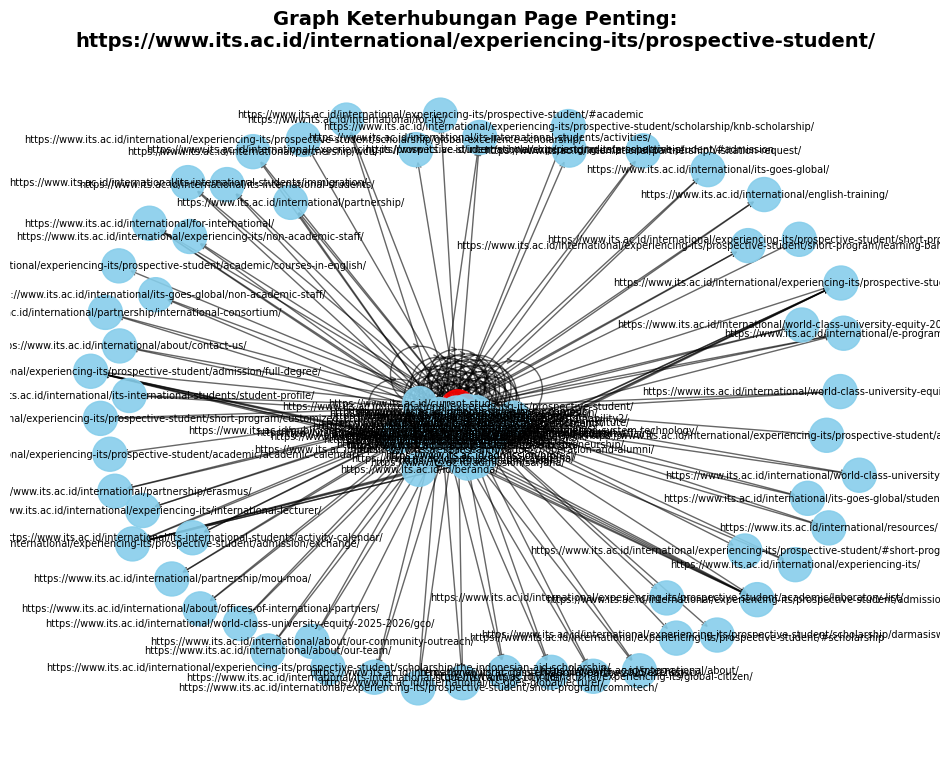

In [ ]:
# Visualisasi Graph
plt.figure(figsize=(12, 9))
plt.title(f"Graph Keterhubungan Page Penting:\n{page_penting}", fontsize=14, fontweight='bold')

pos = nx.spring_layout(subgraph_page_terhubung, seed=42, k=0.3)
warna_page = ['red' if page == page_penting else 'skyblue' for page in subgraph_page_terhubung.nodes()]

nx.draw_networkx_nodes(subgraph_page_terhubung, pos, node_color=warna_page, node_size=600, alpha=0.9)
nx.draw_networkx_edges(subgraph_page_terhubung, pos, edge_color='black', arrowstyle='->', arrowsize=8, alpha=0.6)
nx.draw_networkx_labels(subgraph_page_terhubung, pos, font_size=7, font_color='black')

plt.axis('off')
plt.show()

In [ ]:
# Data Keterhubungan Page Penting
print(f"Jumlah total page yang terhubung dengan page penting: {len(page_terhubung)}")

# DataFrame untuk incoming dan outgoing edges
df_in = pd.DataFrame({
    'page': neighbors_in,
    'link_keluar': [page_penting] * len(neighbors_in)
})
df_out = pd.DataFrame({
    'page': [page_penting] * len(neighbors_out),
    'link_keluar': neighbors_out
})

# gabungkan kedua arah hubungan
data_page_terhubung = pd.concat([df_in, df_out], ignore_index=True)

print(f"Daftar Page yang Terhubung dengan Page Penting:")
display(data_page_terhubung)

Jumlah total page yang terhubung dengan page penting: 104
Daftar Page yang Terhubung dengan Page Penting:


,page,link_keluar
0,https://www.its.ac.id/,https://www.its.ac.id/international/experienci...
1,https://www.its.ac.id/admission/,https://www.its.ac.id/international/experienci...
2,https://www.its.ac.id/current-student/,https://www.its.ac.id/international/experienci...
3,https://www.its.ac.id/fresher/,https://www.its.ac.id/international/experienci...
4,https://www.its.ac.id/lecturer-and-staff/,https://www.its.ac.id/international/experienci...
...,...,...
101,https://www.its.ac.id/international/experienci...,https://www.its.ac.id/international/experienci...
102,https://www.its.ac.id/international/experienci...,https://www.its.ac.id/international/experienci...
103,https://www.its.ac.id/international/experienci...,https://www.its.ac.id/international/experienci...
104,https://www.its.ac.id/international/experienci...,https://www.its.ac.id/international/experienci...
